In [20]:
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import pandas as pd
from sklearn.preprocessing import StandardScaler
import torch.nn.functional as F

# Activation Function

An activation function is a nonlinear transformation applied to the output of a neuron (or layer).

Linear Output −→−−−−− ActivationNonlinear Output

This is the critical step that allows neural networks to:

Model curves, interactions, and complexity
Solve tasks like image classification, speech recognition, and natural language processing
Without activation functions, a neural network is just a linear regression model in disguise!




### Common Activation Functions


### 🔹 ReLU (Rectified Linear Unit)

**Formula:** $f(x) = \max(0, x)$

- Outputs zero if $x < 0$, and $x$ otherwise  
- Very simple and efficient  
- Helps combat the vanishing gradient problem


### 🔹 Sigmoid

**Formula:** $f(x) = \frac{1}{1 + e^{-x}}$

- Squeezes output between **0 and 1**  
- Often used in binary classification problems  
- Can saturate and cause gradients to vanish


### 🔹 Tanh (Hyperbolic Tangent)

**Formula:** $f(x) = \tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$

- Squeezes output between **-1 and 1**  
- Like sigmoid, but **centered at 0**, which often helps training


Each of these functions introduces **nonlinearity**, enabling neural nets to **stack and compose** complex feature transformations.

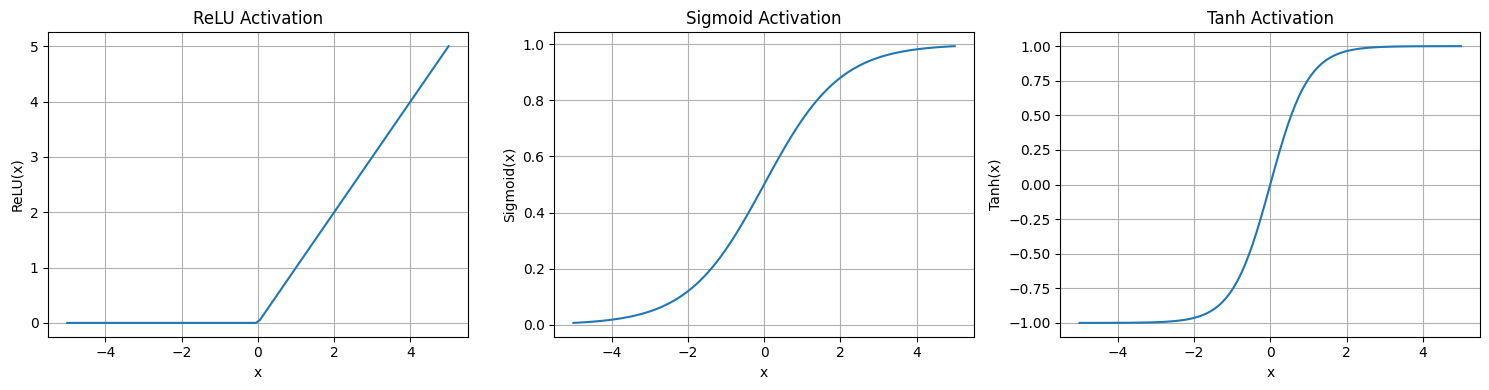

In [3]:
# Create a range of x values
x_vals = torch.linspace(-5, 5, 100)

# Compute outputs
relu = torch.relu(x_vals)
sigmoid = torch.sigmoid(x_vals)
tanh = torch.tanh(x_vals)

# Plot all three functions
plt.figure(figsize=(15, 4))

# ReLU
plt.subplot(1, 3, 1)
plt.plot(x_vals.numpy(), relu.numpy())
plt.title('ReLU Activation')
plt.xlabel('x')
plt.ylabel('ReLU(x)')
plt.grid(True)

# Sigmoid
plt.subplot(1, 3, 2)
plt.plot(x_vals.numpy(), sigmoid.numpy())
plt.title('Sigmoid Activation')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')
plt.grid(True)

# Tanh
plt.subplot(1, 3, 3)
plt.plot(x_vals.numpy(), tanh.numpy())
plt.title('Tanh Activation')
plt.xlabel('x')
plt.ylabel('Tanh(x)')
plt.grid(True)

plt.tight_layout()
plt.show()

# ReLU

ReLU is mathematically defined as:$$\text{ReLU}(z) = \max(0, z)$$It acts as a hard mathematical gate: if the value is less than zero, force it to zero; if it's positive, leave it alone.

In [17]:
def my_relu(x):
    return torch.clamp(x, min=0)


test_x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("Input:", test_x)
print("ReLU Output:", my_relu(test_x))


Input: tensor([-2., -1.,  0.,  1.,  2.])
ReLU Output: tensor([0., 0., 0., 1., 2.])


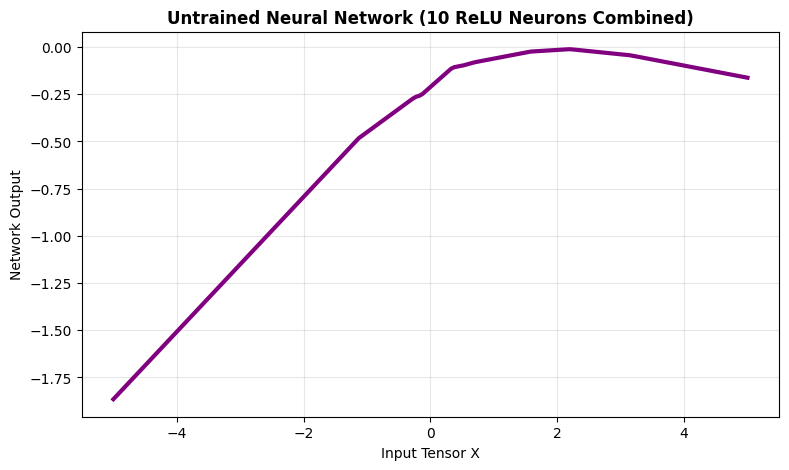

In [7]:
X = torch.linspace(-5, 5, 200).unsqueeze(1)

torch.manual_seed(42)
model = nn.Sequential(
    nn.Linear(1, 10),
    nn.ReLU(),
    nn.Linear(10, 1)
)


with torch.no_grad():
    output = model(X)


plt.figure(figsize=(9, 5))
plt.plot(X.numpy(), output.numpy(), color='purple', linewidth=3)

plt.title('Untrained Neural Network (10 ReLU Neurons Combined)', fontsize=12, fontweight='bold')
plt.xlabel('Input Tensor X', fontsize=10)
plt.ylabel('Network Output', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

# Sigmoid

The formula for the Sigmoid function is:$$\sigma(x) = \frac{1}{1 + e^{-x}}$$Because of how this equation is structured, it behaves exactly like this:

1. Massive Negative Numbers: Get squashed as close to $0.0$ as possible.

2. Zero ($0.0$): Sits perfectly in the middle at $0.5$.

3. Massive Positive Numbers: Get squashed as close to $1.0$ as possible.

In [12]:
# Define Sigmoid manually
def my_sigmoid(x):
    return 1 / (1 + torch.exp(-x))

# Test
test_x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])
print("Input:", test_x)
print("Sigmoid Output:", my_sigmoid(test_x))

Input: tensor([-2., -1.,  0.,  1.,  2.])
Sigmoid Output: tensor([0.1192, 0.2689, 0.5000, 0.7311, 0.8808])


# Tanh Activation Function

The formula for Tanh looks complex:$$\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}$$But its behavior is very straightforward:

1. Massive Negative Numbers: Get squashed flat against $-1.0$.

2. Zero ($0.0$): Passes through exactly as $0.0$.

3. Massive Positive Numbers: Get squashed flat against $1.0$.

In [13]:
def my_tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

# 2. Define the input tensor
test_x = torch.tensor([-2.0, -1.0, 0.0, 1.0, 2.0])

# 4. Print the original input and the output
print("Original input:", test_x)
print("Custom Tanh output:", my_tanh(test_x))

Original input: tensor([-2., -1.,  0.,  1.,  2.])
Custom Tanh output: tensor([-0.9640, -0.7616,  0.0000,  0.7616,  0.9640])


# Softmax

The formula is:

$$\text{Softmax}(x_i) = \frac{e^{x_i}}{\sum e^{x_j}}$$

## Step 1: The Exponential ($e^x$)

It raises the mathematical constant $e$ to the power of each raw score. This forces all negative numbers to become positive, and severely exaggerates the difference between the winner and the losers.

$e^{2.0} \approx 7.39$

$e^{1.0} \approx 2.72$

$e^{-1.0} \approx 0.37$

## Step 2: The Divide (The Percentage Maker)

It adds those new numbers together to get a total sum ($7.39 + 2.72 + 0.37 = \mathbf{10.48}$).

Then, it divides each individual number by that total sum to get its final percentage slice of the pie.

Grade A: $7.39 / 10.48 = \mathbf{0.70}$ (70%)

Grade B: $2.72 / 10.48 = \mathbf{0.26}$ (26%)

Grade C: $0.37 / 10.48 = \mathbf{0.04}$ (4%)

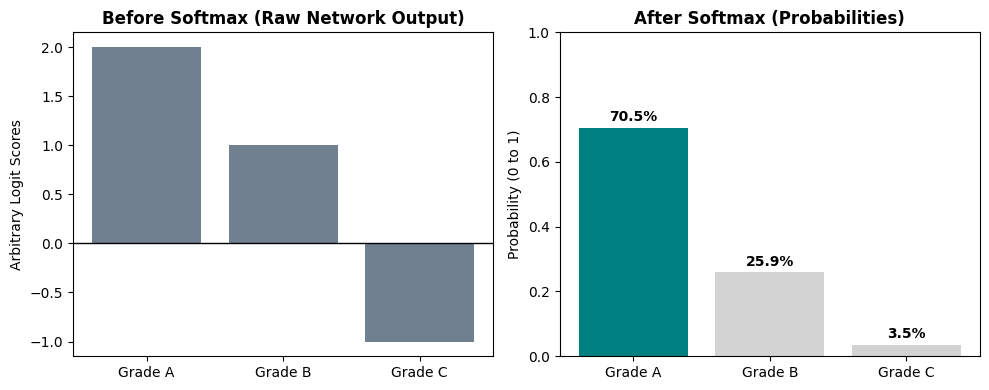

In [15]:
raw_scores = torch.tensor([2.0, 1.0, -1.0])
categories = ['Grade A', 'Grade B', 'Grade C']


probabilities = F.softmax(raw_scores, dim=0)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))


ax1.bar(categories, raw_scores.numpy(), color='slategray')
ax1.set_title('Before Softmax (Raw Network Output)', fontweight='bold')
ax1.set_ylabel('Arbitrary Logit Scores')
ax1.axhline(0, color='black', linewidth=1)


colors = ['teal' if i == torch.argmax(probabilities) else 'lightgray' for i in range(3)]
ax2.bar(categories, probabilities.numpy(), color=colors)
ax2.set_title('After Softmax (Probabilities)', fontweight='bold')
ax2.set_ylabel('Probability (0 to 1)')
ax2.set_ylim(0, 1)

for i, p in enumerate(probabilities):
    ax2.text(i, p.item() + 0.02, f'{p.item()*100:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Applied Non-Linearity To Concrete Data

In [18]:
df = pd.read_csv("/content/drive/MyDrive/concrete_data_clean.csv")
df.head()

,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [19]:
inputs = df.drop('compressive_strength', axis=1).values
targets = df['compressive_strength'].values.reshape(-1, 1)

In [21]:
scaler = StandardScaler()
inputs = scaler.fit_transform(inputs)

In [22]:
input_tensor = torch.tensor(inputs, dtype=torch.float32)
target_tensor = torch.tensor(targets, dtype=torch.float32)

In [24]:
n_samples = input_tensor.shape[0]
indices = torch.randperm(n_samples)
split_idx = int(n_samples * 0.8)

In [26]:
train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train = input_tensor[train_indices]
y_train = target_tensor[train_indices]
X_test = input_tensor[test_indices]
y_test = target_tensor[test_indices]

In [27]:
num_features = X_train.shape[1]
W = torch.randn((num_features, 1), requires_grad=True)
W.data *= 0.01
b = torch.zeros((1,), requires_grad=True)

print("Training set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])
print("Weight shape:", W.shape)
print("Bias shape:", b.shape)

Training set size: 824
Test set size: 206
Weight shape: torch.Size([8, 1])
Bias shape: torch.Size([1])


In [28]:
hidden_units = 16
num_features = X_train.shape[1] # This is 8 from your image


# Linear Layer 1: Maps [Batch, 8] -> [Batch, 16]
W1 = torch.randn((num_features, hidden_units), requires_grad=True)
W1.data *= 0.01
b1 = torch.zeros((1, hidden_units), requires_grad=True)

# Linear Layer 2: Maps [Batch, 16] -> [Batch, 1]
W2 = torch.randn((hidden_units, 1), requires_grad=True)
W2.data *= 0.01
b2 = torch.zeros((1, 1), requires_grad=True)

print("Layer 1 Weights shape:", W1.shape)
print("Layer 2 Weights shape:", W2.shape)


def predict_nonlinear(X):
    # 1. Linear Layer 1 (X @ W1 + b1)
    # The @ symbol performs matrix multiplication
    Z1 = X @ W1 + b1

    # 2. ReLU Activation (Manual non-linear bend)
    A1 = torch.clamp(Z1, min=0)

    # 3. Linear Layer 2 (A1 @ W2 + b2)
    y_hat = A1 @ W2 + b2

    return y_hat

# Test the manual forward pass on the first 5 rows of training data
sample_predictions = predict_nonlinear(X_train[:5])
print("\nSample Predictions shape:", sample_predictions.shape)

Layer 1 Weights shape: torch.Size([8, 16])
Layer 2 Weights shape: torch.Size([16, 1])

Sample Predictions shape: torch.Size([5, 1])


In [30]:
learning_rate = 0.01
epochs = 500

print("Starting Training Loop...\n")

for epoch in range(epochs):

    y_train_pred = predict_nonlinear(X_train)


    loss = torch.mean((y_train_pred - y_train) ** 2)


    loss.backward()


    with torch.no_grad():

        W1 -= learning_rate * W1.grad
        b1 -= learning_rate * b1.grad
        W2 -= learning_rate * W2.grad
        b2 -= learning_rate * b2.grad

        W1.grad.zero_()
        b1.grad.zero_()
        W2.grad.zero_()
        b2.grad.zero_()


    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Training Loss (MSE): {loss.item():.4f}")



def mae_loss(predictions, targets):
    return torch.mean(torch.abs(predictions - targets))

with torch.no_grad():
    final_train_pred = predict_nonlinear(X_train)
    final_test_pred = predict_nonlinear(X_test)

    train_mae = mae_loss(final_train_pred, y_train)
    test_mae = mae_loss(final_test_pred, y_test)

print("\n--- FINAL MAE SCORES ---")
print(f"Train MAE Loss: {train_mae.item():.4f}")
print(f"Test MAE Loss:  {test_mae.item():.4f}")

Starting Training Loop...

Epoch    0 | Training Loss (MSE): 46.0502
Epoch  100 | Training Loss (MSE): 44.8359
Epoch  200 | Training Loss (MSE): 46.8019
Epoch  300 | Training Loss (MSE): 45.2771
Epoch  400 | Training Loss (MSE): 43.6480

--- FINAL MAE SCORES ---
Train MAE Loss: 5.1332
Test MAE Loss:  5.5502


# Insights

## Introducing Non-Linearity ha s lowered significantly from 12.6 to 5.5502